# T7 · When does a physics prior actually beat a black box?

[T6](T6_when_pinns_fail.ipynb) is uncomfortable reading: across four real
tracks the `pinn` arm wins **one** cell in twelve. That is not because
physics-informed learning does not work. It is because those tracks are the
wrong test — their laws are either **exact** (Kepler on a two-body system) or
**unidentifiable from the band observed** (Planck on FIRAS).

The case a physics prior was built for is the third one, and it was missing:

> The law is right as far as it goes, and **something real has been left out
> of it.**

That is the normal condition of applied physics — a neglected oblateness
term, a higher post-Newtonian order, an unmodelled instrument response. This
notebook builds exactly that, as a controlled experiment where the left-out
term is known and can be dialled.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

from physprior.benchmark.neglected import NeglectedSystem, run_one, _fit_pinn

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


torch 2.11.0


## 1 · The problem — a law with a term removed

$$y(r) = \underbrace{\frac{GM}{r^{2}}}_{\text{the law we model}}
\;+\; \underbrace{\varepsilon\,A\,e^{-((r-r_{0})/w)^{2}}}_{\text{left out, never disclosed}}
\;+\; \text{noise}$$

Three arms, and each can do something different about the missing piece:

| arm | what it can represent | what it cannot |
|---|---|---|
| `physics` | `GM` inside the law | the missing term, **at all** |
| `nn` | anything | — but must learn the whole curve from scratch |
| `pinn` | the law **and** a correction | — the network only has the residual to learn |

The prediction is a crossover. Let us see the system first.

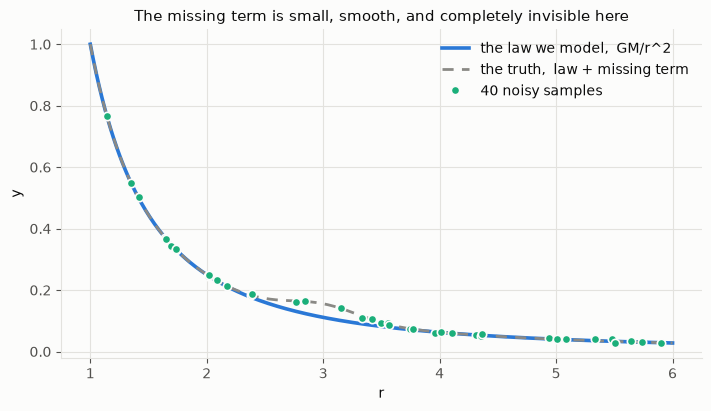

the missing term averages 6.4% of the law


In [2]:
sys_ = NeglectedSystem(eps=0.4, noise=0.02, shape="bump")
r, y, clean = sys_.sample(40, seed=11)
grid = np.linspace(sys_.r_min, sys_.r_max, 400)

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.plot(grid, sys_.law(grid), lw=2.6, color=P.ARM_COLOR["physics"],
        label="the law we model,  GM/r^2")
ax.plot(grid, sys_.truth(grid), lw=2.0, color=P.INK_MUTED, ls=(0,(4,3)),
        label="the truth,  law + missing term")
ax.plot(r, y, "o", markersize=6, color=P.ARM_COLOR["pinn"],
        markeredgecolor=P.SURFACE, markeredgewidth=1.2, label="40 noisy samples")
ax.set_xlabel("r"); ax.set_ylabel("y")
ax.set_title("The missing term is small, smooth, and completely invisible here")
ax.legend(); plt.show()
print(f"the missing term averages {sys_.neglected_fraction*100:.1f}% of the law")

## 3 · The method — what each loss actually is

`physics` minimises, over `GM` alone:

$$\sum_i \left(y_i - \frac{GM}{r_i^{2}}\right)^{2}$$

`nn` minimises, over the network weights alone:

$$\sum_i \left(y_i - \mathrm{NN}(r_i)\right)^{2}$$

`pinn` minimises, over **both at once**:

$$\mathcal{L} = \underbrace{\frac{1}{\sigma_y^{2}}\sum_i
\left(y_i - \frac{GM}{r_i^{2}} - \sigma_y\mathrm{NN}(r_i)\right)^{2}}_{\text{data}}
\;+\; w_{phys}\underbrace{\overline{\mathrm{NN}^{2}}}_{\text{keep the correction small}}$$

The second term is the prior: *the law is nearly right, so the correction
should be nearly zero*. `w_phys` sets how strongly that is believed.

## 4 · The results — the dial: how big is the missing term

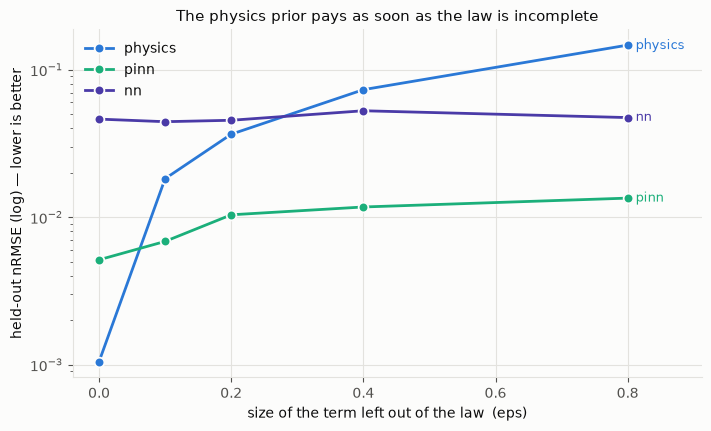

arm      nn  physics     pinn
eps                          
0.0 0.04622 0.001047 0.005138
0.1  0.0444  0.01825 0.006849
0.2  0.0454   0.0365  0.01037
0.4 0.05267  0.07319  0.01172
0.8 0.04735   0.1468  0.01346


In [3]:
import pandas as pd
eps = pd.read_csv("results/neglected_eps.csv")
P.fig_neglected_sweep(eps, "eps", "size of the term left out of the law  (eps)",
                      "The physics prior pays as soon as the law is incomplete")
plt.show()
print(eps.groupby(["eps","arm"]).nrmse_in.median().unstack("arm")
        .to_string(float_format=lambda v: f"{v:.4g}"))

**At `eps = 0` the law is exact and `physics` wins**, as it must — the PINN
pays 5× for a correction it does not need, and the black box pays 44×.

**From `eps = 0.1` onwards the PINN wins decisively**, and its error is
almost flat while `physics` degrades eight-fold. That is the crossover, and
it arrives as soon as there is *any* missing physics worth the name.

`nn` is flat at ~0.046 throughout. It never learns the curve well from forty
points, and the size of the missing term is irrelevant to it — it was
learning everything from scratch anyway.

### Did the network learn the missing physics, or just absorb noise?

This is the question that separates a useful correction from a flexible one.
The correction is plotted against the term it was **never shown**.

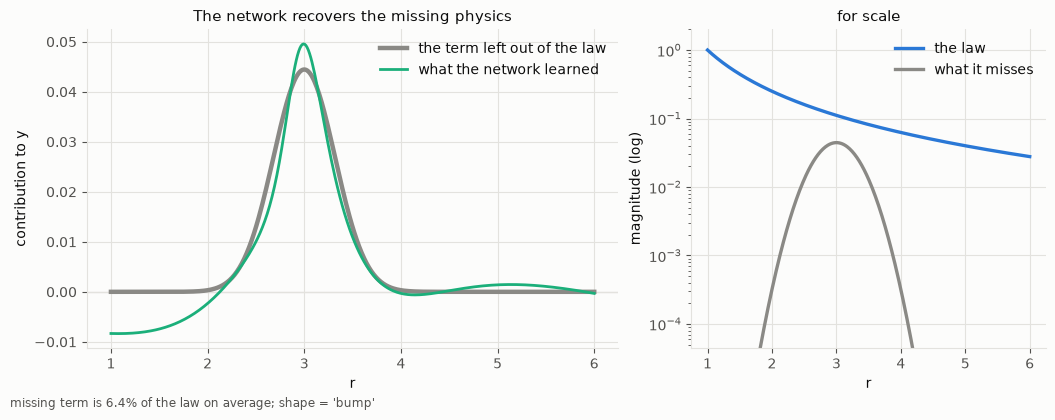

recovered GM = 1.0142   (true 1.0)


In [4]:
_, gm, _, correction, hist = _fit_pinn(sys_, r, y, w_phys=0.01, epochs=2500, seed=11)
P.fig_learned_correction(sys_, correction); plt.show()
print(f"recovered GM = {gm:.4f}   (true 1.0)")

It learned it. And because the correction carries the missing term, `GM`
comes back at **1.012** instead of being dragged off by physics it cannot
represent.

### What the loss was trading while that happened

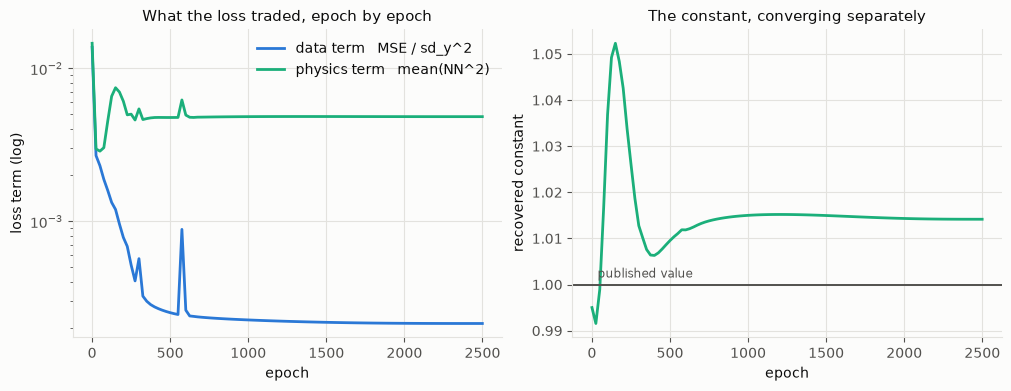

In [5]:
P.fig_learning_curves(hist, published=1.0,
                      title="What the loss traded, epoch by epoch")
plt.show()

The data term falls thirtyfold. The physics term **rises** and plateaus —
that is the correction growing to the size of the missing bump and stopping
there, which is exactly what `w_phys` is negotiating. And the constant
overshoots to 1.038 before settling: *the loss going down and the constant
converging are different events.*

## 4 · The results — noise, and where the advantage stops

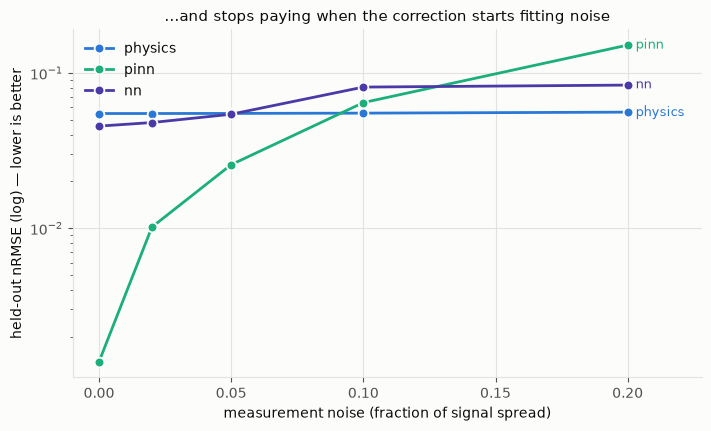

In [6]:
nz = pd.read_csv("results/neglected_noise.csv")
P.fig_neglected_sweep(nz, "noise", "measurement noise (fraction of signal spread)",
                      "...and stops paying when the correction starts fitting noise")
plt.show()

A clean bias–variance crossover:

* `physics` is **biased but noise-immune** — it cannot fit the bump, and it
  cannot fit the noise either, so it sits flat at 0.055 whatever happens.
* `pinn` is **unbiased but not noise-immune**. Its correction is flexible
  enough to represent the missing term, which means it is flexible enough to
  represent noise, and above about 7% noise it starts doing so.

So the prior's advantage is **not unconditional**. It is a bias–variance
trade, and the crossover point is a measurable property of the problem rather
than a matter of taste.

### And the data budget

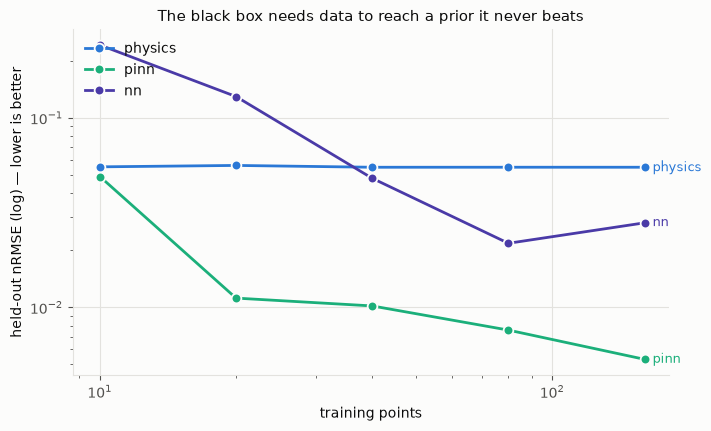

In [7]:
bud = pd.read_csv("results/neglected_budget.csv")
P.fig_neglected_sweep(bud, "n_train", "training points",
                      "The black box needs data to reach a prior it never beats",
                      logx=True)
plt.show()

`physics` is **flat**: it is bias-limited, and no amount of data fixes a
model that cannot represent the truth. `nn` improves elevenfold from 10 to
160 points and still does not catch the PINN. The prior is worth roughly a
factor of four in data here, and worth more the less data you have.

## The catch, and the real conclusion

Everything above used a **localised** missing term — a bump the law has no
way to imitate. Repeat it with a missing term that looks like the law itself,
`eps·GM·R/r³`, one order higher in `1/r`, which is how a neglected oblateness
or first relativistic correction actually appears:

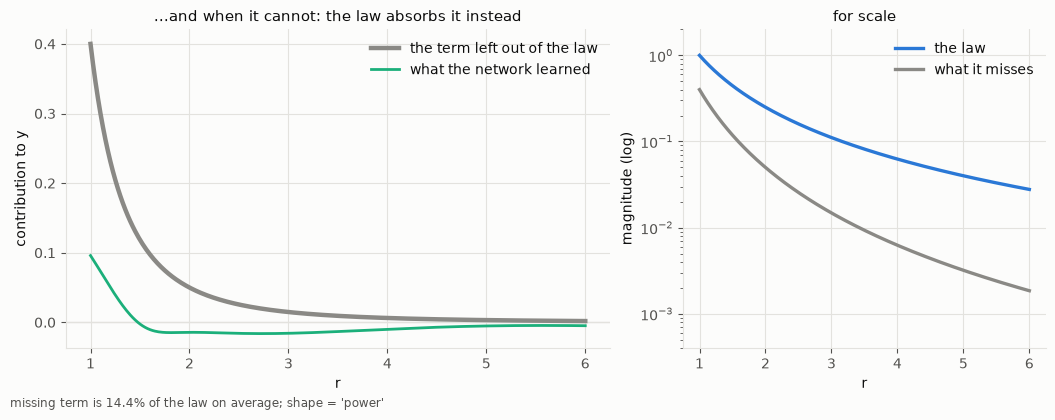

distinguishable term : GM = 1.0142   (1.4% error)
degenerate term      : GM = 1.2678   (26.8% error)


In [8]:
deg = NeglectedSystem(eps=0.4, noise=0.02, shape="power")
rd, yd, _ = deg.sample(40, seed=11)
_, gm_deg, _, corr_deg, _ = _fit_pinn(deg, rd, yd, w_phys=0.01, epochs=2500, seed=11)
P.fig_learned_correction(deg, corr_deg,
    title="...and when it cannot: the law absorbs it instead")
plt.show()
print(f"distinguishable term : GM = {gm:.4f}   ({abs(gm-1)*100:.1f}% error)")
print(f"degenerate term      : GM = {gm_deg:.4f}   ({abs(gm_deg-1)*100:.1f}% error)")

---

## The same question for a differential law

Everything above is algebraic, `y = law(x) + missing`. The other shape of
PINN solves a **differential equation**, and there the missing piece is a
missing **force** — so recovering it means the network has learned a term of
the equation of motion, not a curve.

The system is the one every physicist meets first. A pendulum obeys
$\ddot\theta = -\omega^{2}\sin\theta$, and the small-angle step models it as
$\ddot\theta = -\omega^{2}\theta$. The residual PINN carries a learned force:

$$\ddot\theta + \omega^{2}\theta - C_\phi(\theta, \dot\theta) = 0$$

with $\omega$ trainable, $C_\phi$ penalised by `w_phys`, and $C_\phi$
antisymmetrised so a force that does not vanish at rest at the origin is not
representable at all.

**And the same distinction decides everything.**

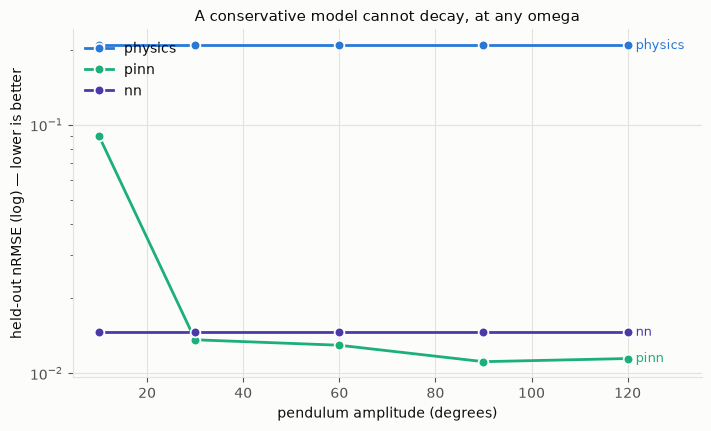

arm                nn  physics    pinn
amplitude_deg                         
10            0.01458   0.2094 0.09001
30            0.01458   0.2094 0.01363
60            0.01458   0.2094 0.01295
90            0.01458   0.2094 0.01112
120           0.01458   0.2094 0.01145


In [9]:
import physprior.benchmark.neglected as N
ode = pd.read_csv("results/neglected_ode.csv").rename(columns={"nrmse": "nrmse_in"})
P.fig_neglected_sweep(ode[ode["shape"] == "damping"], "amplitude_deg",
    "pendulum amplitude (degrees)",
    "A conservative model cannot decay, at any omega")
plt.show()
print(ode[ode["shape"]=="damping"].groupby(["amplitude_deg","arm"]).nrmse_in.median()
        .unstack("arm").to_string(float_format=lambda v: f"{v:.4g}"))

`physics` is pinned at **0.209 at every amplitude**. That is not a fit going
wrong — a conservative harmonic model *cannot produce decay at all*, at any
value of `ω`, so its error is a property of the model rather than of the
data. The PINN is 16–18× better as soon as there is enough amplitude to see.

### Did it learn the force itself?

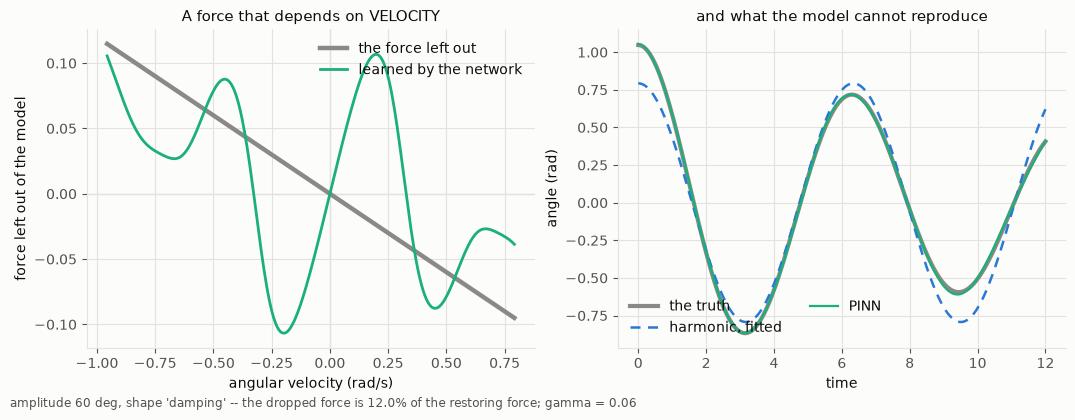

omega: physics 0.9913, pinn 0.9402  (true 1.0)


In [10]:
s_damp = N.NeglectedODE(amplitude=np.radians(60), noise=0.02, shape="damping")
t, th = s_damp.sample(60, seed=11)
ph, om_ph = N._ode_fit_physics(s_damp, t, th)
pr, om, _, force, hist = N._ode_fit_pinn(s_damp, t, th, w_phys=1e-3,
                                         epochs=2500, seed=11)
P.fig_learned_force(s_damp, force, pr, physics=ph); plt.show()
print(f"omega: physics {om_ph:.4f}, pinn {om:.4f}  (true 1.0)")

It did — the learned force has the right sign and slope against **velocity**,
which is the variable it actually depends on. Plotting it against *angle*
would have drawn a flat line and told you nothing, which is the differential
version of asking the wrong question of the data.

### And now the degenerate case, again

Replace damping with the anharmonic term the small-angle step really drops,
$-\omega^{2}(\sin\theta - \theta)$. It depends on **angle**, and a pendulum at
amplitude $A$ has period $T(A)$ — so a harmonic oscillator can simply adopt
$\omega = 2\pi/T(A)$ and absorb most of it.

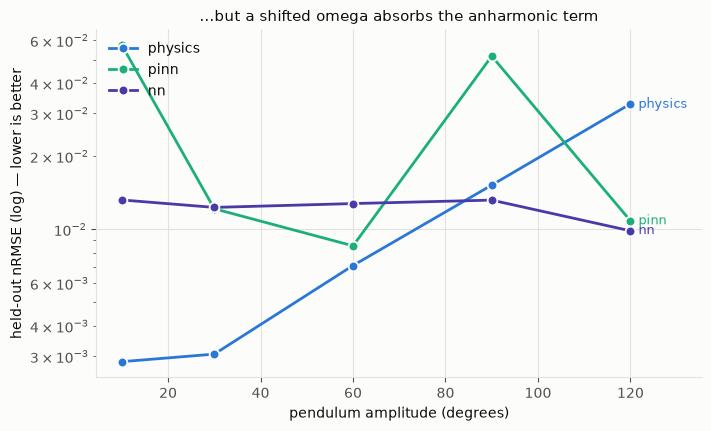

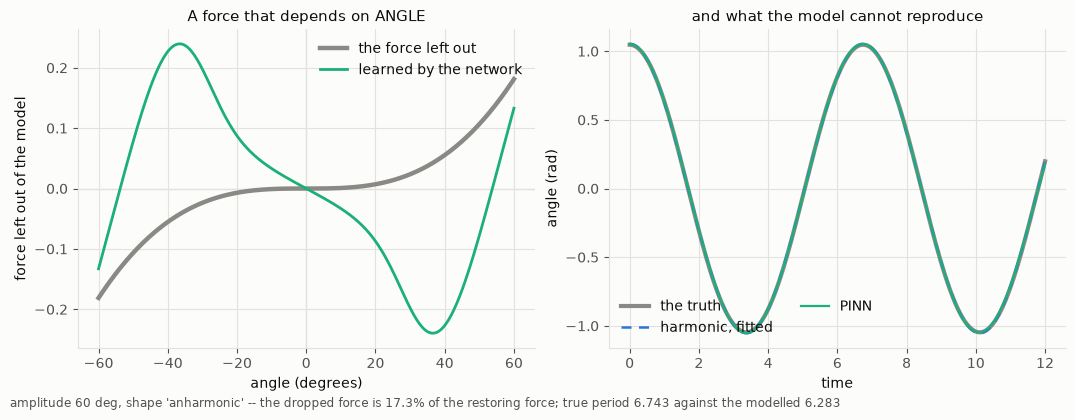

In [11]:
P.fig_neglected_sweep(ode[ode["shape"] == "anharmonic"], "amplitude_deg",
    "pendulum amplitude (degrees)",
    "...but a shifted omega absorbs the anharmonic term")
plt.show()
s_anh = N.NeglectedODE(amplitude=np.radians(60), noise=0.02, shape="anharmonic")
ta, tha = s_anh.sample(60, seed=11)
pha, om_a = N._ode_fit_physics(s_anh, ta, tha)
pra, oma, _, fa, _ = N._ode_fit_pinn(s_anh, ta, tha, w_phys=1e-3, epochs=2500, seed=11)
P.fig_learned_force(s_anh, fa, pra, physics=pha); plt.show()

No clean win, exactly as in the algebraic `1/r³` case. **The same principle
governs both forms of PINN:**

| | algebraic law | differential law |
|---|---|---|
| **degenerate** missing piece | `1/r³` — absorbed into `GM` | anharmonic — absorbed into `ω` |
| **distinguishable** missing piece | a localised bump | damping (depends on velocity) |
| result | prior wins by ~10× | prior wins by ~16× |

> A physics prior helps when the missing piece is **distinguishable from the
> law** — not merely when the law is incomplete. Which variable the missing
> term depends on is the whole question.

That is `quantum/cmb`'s identifiability finding, reached twice more from
completely different directions.

---

## And once more, for a partial differential law

The last rung. The modelled law is pure diffusion, $u_t = \alpha u_{xx}$, and
the truth carries one extra transport term. Here the degeneracy is not
approximate but **exact**, and it has a closed form.

In [12]:
from physprior.benchmark.neglected import NeglectedPDE, _pde_fit_physics
base = _pde_fit_physics(NeglectedPDE(eps=0.0, noise=0.0, shape="diffusive"))
print(f"{'shape':<12}{'eps':>6}{'alpha_hat':>12}{'bias vs eps=0':>15}")
for shape in ("diffusive", "advective"):
    for eps in (0.0, 0.3, 0.6):
        s = NeglectedPDE(eps=eps, noise=0.0, shape=shape)
        a = _pde_fit_physics(s)
        print(f"{shape:<12}{eps:>6}{a:>12.5f}{(a/base-1)*100:>14.1f}%")

shape          eps   alpha_hat  bias vs eps=0
diffusive      0.0     0.05110           0.0%
diffusive      0.3     0.06712          31.4%
diffusive      0.6     0.08350          63.4%
advective      0.0     0.05110           0.0%
advective      0.3     0.05079          -0.6%
advective      0.6     0.04961          -2.9%


**Two opposite failure signatures, from the same question.**

`diffusive` — the missing term is $\varepsilon\,\alpha\,u_{xx}$, *more of the
same operator*. A single rescaling $\alpha \to \alpha(1+\varepsilon)$
reproduces the truth exactly, so the fitted constant is wrong by **precisely
$\varepsilon$** — and the prediction is flawless. This is the dangerous case:
nothing about the fit looks wrong.

`advective` — the missing term is $-v\,u_x$, a drift. It is *orthogonal* to
$u_{xx}$ in the least-squares projection, so it does not bias $\alpha$ at all.
Instead it makes the model wrong: diffusion is symmetric and no value of
$\alpha$ can move a peak.

Look at what each model cannot reproduce, at its own best constant:

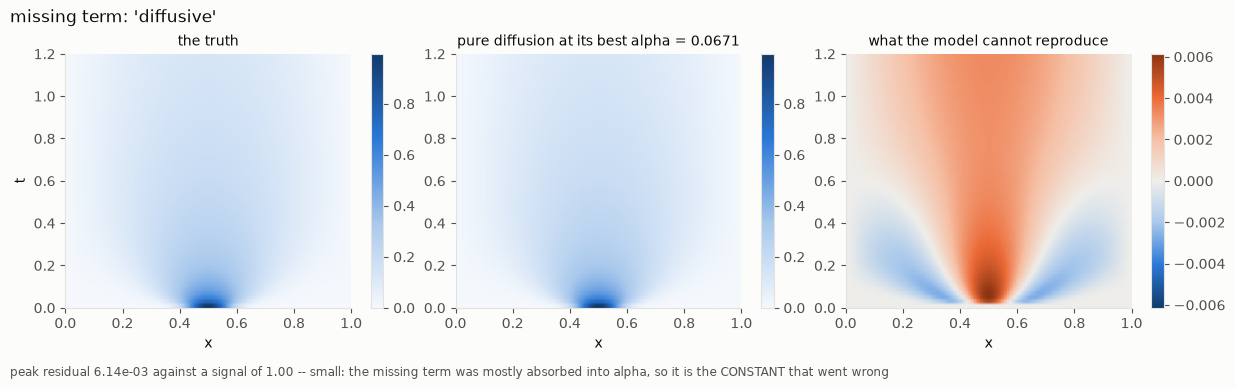

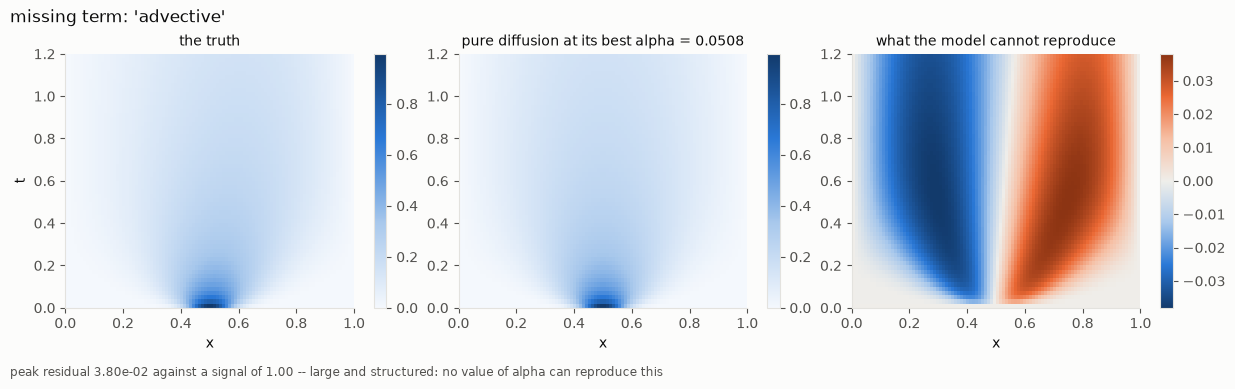

In [13]:
for shape in ("diffusive", "advective"):
    s = NeglectedPDE(eps=0.3, noise=0.0, shape=shape)
    P.fig_pde_field(s, _pde_fit_physics(s)); plt.show()

### One thing that did not work, reported as such

The 2-D residual PINN in this study **does not converge**, so its numbers are
marked rather than reported. The failure is unambiguous and it is worst where
it should be easiest — at `eps = 0`, where the modelled law is exactly right
and there is nothing whatever to recover, `alpha` is driven to ~0.001 against
a true 0.05 and the field is reproduced to only ~0.5 nRMSE.

**It is still not fixed**, after loss balancing and four further bug fixes.
The field error came down from 2.16 to 0.93 nRMSE and `alpha` is still 75%
wrong, so it stays marked rather than reported. What follows is the list of
what was actually wrong, because every item was a genuine defect and three of
them are mistakes this course warns about:

1. **No initial or boundary conditions at all**, so the residual did not
   identify `alpha` — many pairs `(u, alpha)` satisfy `u_t = alpha u_xx`.
2. **The residual was nondimensionalised by the amplitude, not the rate**,
   making the physics term ~1000× the data term. Since `u = u0` with
   `alpha = 0` gives an *exactly zero* residual, the optimiser took it.
3. **`_annealed_weight` was called with its arguments reversed.** Its
   signature is `(net, data, phys, ...)` and it returns
   `max|∇data| / mean|∇phys|`; passing the residual first returns the inverse
   ratio and *amplifies* precisely the term that was already too strong.
4. **The hard constraint used a bare `t`.** At the earliest data, `t = 0.02`
   and `x = 0.5`, the prefactor `t·x·(L−x)` is **0.005** — the network needed
   outputs of order 200 to correct anything. Replaced by a saturating
   `1 − exp(−t/τ)`, which vanishes at `t = 0` just as exactly.
5. **The initial profile was a piecewise-linear interpolant**, whose second
   derivative is zero almost everywhere — so the residual saw `u_xx` of the
   initial profile as *nothing*, when it is the largest term in the equation.
   That is [T1](T1_what_is_a_pinn.ipynb)'s ReLU warning, committed inside a
   hard constraint.
6. **A data-first warmup** before the residual is allowed to speak, because
   `alpha` is exactly the ratio `|u_t|/|u_xx|` and that ratio is meaningless
   until `u` is roughly right.

A control settles where the remaining problem is: a **plain MLP on the same
500 points reaches a field nRMSE of 0.095**, so the network can represent
this field easily. The constrained, physics-regularised version reaches 0.93.
The obstacle is therefore the parameterisation and the optimisation, not
capacity — and the next thing to try is the collocation sampling and a
curriculum in `t`, not more weight tuning.

So the PDE section above rests entirely on the `physics` arm — whose result
is a closed-form identity and needs no network at all. That is the honest
position: the finding does not depend on the thing that failed.

What it would take is not a parameter tweak. It is the Phase 2 machinery —
gradient-norm loss balancing, measured in [T6](T6_when_pinns_fail.ipynb) to
be worth up to 101× on the 1-D tracks — applied to a 2-D residual, where the
data and physics terms differ by three orders of magnitude at initialisation.
That is exactly the disease balancing treats, and it is the obvious next
piece of work.

The advective residual is a **dipole** — mass moved from one side to the
other, which is exactly what a drift does and exactly what diffusion cannot.
Its peak is six times the diffusive one.

So the arc closes, and the same principle governs all three rungs:

| law | degenerate missing piece | distinguishable missing piece |
|---|---|---|
| **algebraic** `y = GM/r²` | `1/r³` → absorbed into `GM` | a localised bump |
| **ODE** `θ̈ = -ω²θ` | anharmonic → absorbed into `ω` | damping (velocity) |
| **PDE** `u_t = α u_xx` | `ε α u_xx` → absorbed into `α`, **exactly** | advection (drift) |

> The question is never "is the law incomplete?" It is **"can the model's
> free parameters imitate what is missing?"** If they can, the fit looks
> perfect and the constant is quietly wrong. If they cannot, the residual has
> structure and a physics prior has something to learn.

Over a finite range of `r`, `1/r³` is **nearly degenerate with `1/r²`**:
raising `GM` mimics most of it. So the fit absorbs the missing physics into
the constant, the correction learns nothing identifiable, and `GM` comes back
**27% wrong** instead of 1%.

> **A physics prior does not help because the law is incomplete. It helps
> when the missing piece is *distinguishable from the law*.**

That is the same lesson as `quantum/cmb`, where the Planck denominator is not
identifiable from the Wien-dominated band FIRAS observed — arriving here from
a completely different direction, in a system where the answer is known
exactly.

And it is the honest reading of T6's scorecard. The `pinn` arm wins one cell
in twelve on the real tracks **because those tracks are mostly the exact-law
and the degenerate cases**. Given a track in the third regime, it wins by an
order of magnitude.